

### Main Week 4 question

As the RL policy changes over training, should the predictor adapt using:

1. a frozen **Static** Week 3 predictor,
2. **Periodic Refit**, or
3. **EWMA** online updates?

We evaluate all three on the **same 500-step trace**.

Required checkpoints:

\[
100,\ 200,\ 300,\ 400,\ 500
\]

Required metrics:

- response-length MAE,
- per-class difficulty AUROC,
- calibration.

### Week 3 context

Week 3 showed that the 10 handcrafted prompt features are a major bottleneck.

So Week 4 asks a different question:

Can online updating stop an imperfect predictor from going stale?

In [8]:
from pathlib import Path

TRACE_DIR = Path(
    r"C:\Users\waqar\OneDrive\Desktop\Fellowship\trace_rollout_training_steps"
)

print("Folder exists:", TRACE_DIR.exists())

# print("\nEverything inside recursively:")
# all_files = [p for p in TRACE_DIR.rglob("*") if p.is_file()]

# for f in all_files:
#     print(f.relative_to(TRACE_DIR), "->", repr(f.suffix))
# Sort the 16 rollout files numerically: 1, 2, 3 ... 16

json_files = sorted(
    [
        p for p in TRACE_DIR.rglob("*")
        if p.is_file() and p.suffix.lower() in [".json", ".jsonl"]
    ],
    key=lambda p: int(p.stem)
)

print("Files found:", len(json_files))

for f in json_files:
    print(f.name)

# print("\nTotal files:", len(all_files))

Folder exists: True
Files found: 16
1.jsonl
2.jsonl
3.jsonl
4.jsonl
5.jsonl
6.jsonl
7.jsonl
8.jsonl
9.jsonl
10.jsonl
11.jsonl
12.jsonl
13.jsonl
14.jsonl
15.jsonl
16.jsonl


In [9]:
import pandas as pd

frames = []

for f in json_files:
    df = pd.read_json(f, lines=True)

    # preserve temporal order from filename
    df["batch_step"] = int(f.stem)
    df["source_file"] = f.name

    frames.append(df)

# merge all 16 files
raw_trace = pd.concat(frames, ignore_index=True)

print("Raw merged rows:", len(raw_trace))

# identify padding
is_blank_input = (
    raw_trace["input"]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("")
)

is_pad_uid = (
    raw_trace["uid"]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.startswith("pad")
)

is_padding = is_blank_input | is_pad_uid

# remove padding
clean_trace = (
    raw_trace.loc[~is_padding]
    .copy()
    .reset_index(drop=True)
)

print("Padding rows removed:", is_padding.sum())
print("Clean rows:", len(clean_trace))

print("\nBatch range:")
print(clean_trace["batch_step"].min(), "->", clean_trace["batch_step"].max())

print("\nRows per batch:")
print(clean_trace.groupby("batch_step").size())

Raw merged rows: 10240
Padding rows removed: 0
Clean rows: 10240

Batch range:
1 -> 16

Rows per batch:
batch_step
1     640
2     640
3     640
4     640
5     640
6     640
7     640
8     640
9     640
10    640
11    640
12    640
13    640
14    640
15    640
16    640
dtype: int64


In [10]:
print("Rollouts per prompt per batch:")
print(
    clean_trace
    .groupby(["batch_step", "input"])
    .size()
    .value_counts()
    .sort_index()
)

print("\nUnique prompts per batch:")
print(
    clean_trace
    .groupby("batch_step")["input"]
    .nunique()
)

print("\nPass rate per batch:")
print(
    clean_trace
    .groupby("batch_step")["score"]
    .mean()
    .round(4)
)

print("\nDuplicate UIDs:")
print(clean_trace["uid"].duplicated().sum())

print("\nExact duplicate rows:")
print(clean_trace.duplicated().sum())

Rollouts per prompt per batch:
5     2042
10       3
Name: count, dtype: int64

Unique prompts per batch:
batch_step
1     128
2     128
3     128
4     128
5     128
6     128
7     128
8     128
9     128
10    128
11    128
12    128
13    128
14    128
15    125
16    128
Name: input, dtype: int64

Pass rate per batch:
batch_step
1     0.2141
2     0.2094
3     0.2312
4     0.2078
5     0.2203
6     0.2578
7     0.2047
8     0.2719
9     0.2828
10    0.3453
11    0.3125
12    0.3984
13    0.3609
14    0.4688
15    0.4391
16    0.4234
Name: score, dtype: float64

Duplicate UIDs:
0

Exact duplicate rows:
0


In [11]:
# Remove the final two numeric UID components
# example:
# abc-uuid_3_0 -> abc-uuid

clean_trace["prompt_id"] = (
    clean_trace["uid"]
    .astype(str)
    .str.replace(r"_\d+_\d+$", "", regex=True)
)

print("Example UID → prompt_id:")
display(
    clean_trace[
        ["uid", "prompt_id", "batch_step", "input"]
    ].head(10)
)

print("\nRollouts per true prompt instance:")
print(
    clean_trace
    .groupby(["batch_step", "prompt_id"])
    .size()
    .value_counts()
    .sort_index()
)

print("\nPrompt instances per batch:")
print(
    clean_trace
    .groupby("batch_step")["prompt_id"]
    .nunique()
)

Example UID → prompt_id:


,uid,prompt_id,batch_step,input
0,02a0d5cc-bd9f-4dd6-8906-79b9714021d5_0_0,02a0d5cc-bd9f-4dd6-8906-79b9714021d5,1,"system\nPlease reason step by step, and put yo..."
1,02a0d5cc-bd9f-4dd6-8906-79b9714021d5_1_0,02a0d5cc-bd9f-4dd6-8906-79b9714021d5,1,"system\nPlease reason step by step, and put yo..."
2,02a0d5cc-bd9f-4dd6-8906-79b9714021d5_2_0,02a0d5cc-bd9f-4dd6-8906-79b9714021d5,1,"system\nPlease reason step by step, and put yo..."
3,02a0d5cc-bd9f-4dd6-8906-79b9714021d5_3_0,02a0d5cc-bd9f-4dd6-8906-79b9714021d5,1,"system\nPlease reason step by step, and put yo..."
4,02a0d5cc-bd9f-4dd6-8906-79b9714021d5_4_0,02a0d5cc-bd9f-4dd6-8906-79b9714021d5,1,"system\nPlease reason step by step, and put yo..."
5,03d9b22f-128c-470d-8f14-e428ea341c31_0_0,03d9b22f-128c-470d-8f14-e428ea341c31,1,"system\nPlease reason step by step, and put yo..."
6,03d9b22f-128c-470d-8f14-e428ea341c31_1_0,03d9b22f-128c-470d-8f14-e428ea341c31,1,"system\nPlease reason step by step, and put yo..."
7,03d9b22f-128c-470d-8f14-e428ea341c31_2_0,03d9b22f-128c-470d-8f14-e428ea341c31,1,"system\nPlease reason step by step, and put yo..."
8,03d9b22f-128c-470d-8f14-e428ea341c31_3_0,03d9b22f-128c-470d-8f14-e428ea341c31,1,"system\nPlease reason step by step, and put yo..."
9,03d9b22f-128c-470d-8f14-e428ea341c31_4_0,03d9b22f-128c-470d-8f14-e428ea341c31,1,"system\nPlease reason step by step, and put yo..."



Rollouts per true prompt instance:
5    2048
Name: count, dtype: int64

Prompt instances per batch:
batch_step
1     128
2     128
3     128
4     128
5     128
6     128
7     128
8     128
9     128
10    128
11    128
12    128
13    128
14    128
15    128
16    128
Name: prompt_id, dtype: int64


In [12]:
from transformers import AutoTokenizer
import pandas as pd

tokenizer = AutoTokenizer.from_pretrained(
    "Qwen/Qwen2.5-Math-1.5B"
)

def count_response_tokens(text):
    if pd.isna(text):
        return 0

    return len(
        tokenizer.encode(
            str(text),
            add_special_tokens=False
        )
    )

clean_trace["resp_len"] = (
    clean_trace["output"]
    .apply(count_response_tokens)
)

print(clean_trace["resp_len"].describe())

c:\Users\waqar\OneDrive\Desktop\Fellowship\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


count    10240.000000
mean       815.921680
std        897.290787
min          1.000000
25%        272.000000
50%        418.000000
75%        928.000000
max       5563.000000
Name: resp_len, dtype: float64


In [13]:
prompt_trace = (
    clean_trace
    .groupby(
        ["batch_step", "prompt_id"],
        as_index=False
    )
    .agg(
        input=("input", "first"),
        mean_resp_len=("resp_len", "mean"),
        pass_rate=("score", "mean"),
        reward_var=("score", lambda x: x.var(ddof=0)),
        n_rollouts=("score", "size"),
    )
)

print("Shape:", prompt_trace.shape)

print("\nRollouts per prompt:")
print(prompt_trace["n_rollouts"].value_counts())

print("\nBatch range:")
print(
    prompt_trace["batch_step"].min(),
    "->",
    prompt_trace["batch_step"].max()
)

print("\nPrompt observations per batch:")
print(
    prompt_trace
    .groupby("batch_step")
    .size()
)

Shape: (2048, 7)

Rollouts per prompt:
n_rollouts
5    2048
Name: count, dtype: int64

Batch range:
1 -> 16

Prompt observations per batch:
batch_step
1     128
2     128
3     128
4     128
5     128
6     128
7     128
8     128
9     128
10    128
11    128
12    128
13    128
14    128
15    128
16    128
dtype: int64


In [14]:
def assign_difficulty(pass_rate):
    if pass_rate == 1.0:
        return 0   # Easy
    elif pass_rate == 0.0:
        return 2   # Hard
    else:
        return 1   # Productive

prompt_trace["difficulty"] = (
    prompt_trace["pass_rate"]
    .apply(assign_difficulty)
)

In [15]:
batch_summary = (
    prompt_trace
    .groupby("batch_step")
    .agg(
        n_prompts=("prompt_id", "size"),
        mean_resp_len=("mean_resp_len", "mean"),
        median_resp_len=("mean_resp_len", "median"),
        mean_pass_rate=("pass_rate", "mean"),
        mean_reward_var=("reward_var", "mean"),
    )
)

difficulty_counts = (
    prompt_trace
    .groupby(["batch_step", "difficulty"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={
        0: "Easy",
        1: "Productive",
        2: "Hard"
    })
)

batch_summary = batch_summary.join(difficulty_counts)

for col in ["Easy", "Productive", "Hard"]:
    batch_summary[f"{col}_frac"] = (
        batch_summary[col] / batch_summary["n_prompts"]
    )

display(
    batch_summary[
        [
            "mean_resp_len",
            "median_resp_len",
            "mean_pass_rate",
            "Easy",
            "Productive",
            "Hard",
            "Easy_frac",
            "Productive_frac",
            "Hard_frac",
        ]
    ].round(3)
)

,mean_resp_len,median_resp_len,mean_pass_rate,Easy,Productive,Hard,Easy_frac,Productive_frac,Hard_frac
batch_step,,,,,,,,,
1,963.841,939.2,0.214,0,77,51,0.000,0.602,0.398
2,875.252,844.5,0.209,1,81,46,0.008,0.633,0.359
3,841.138,830.3,0.231,1,82,45,0.008,0.641,0.352
4,840.991,798.8,0.208,0,79,49,0.000,0.617,0.383
5,937.039,895.9,0.220,0,79,49,0.000,0.617,0.383
6,839.109,788.3,0.258,4,82,42,0.031,0.641,0.328
7,831.795,825.4,0.205,2,75,51,0.016,0.586,0.398
8,915.588,871.0,0.272,3,83,42,0.023,0.648,0.328
9,884.973,830.1,0.283,2,83,43,0.016,0.648,0.336


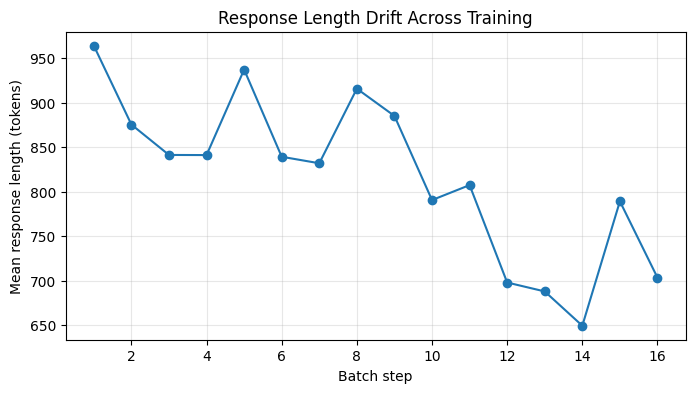

In [16]:
import matplotlib.pyplot as plt

# Response length drift
plt.figure(figsize=(8, 4))
plt.plot(
    batch_summary.index,
    batch_summary["mean_resp_len"],
    marker="o"
)
plt.xlabel("Batch step")
plt.ylabel("Mean response length (tokens)")
plt.title("Response Length Drift Across Training")
plt.grid(alpha=0.3)
plt.show()

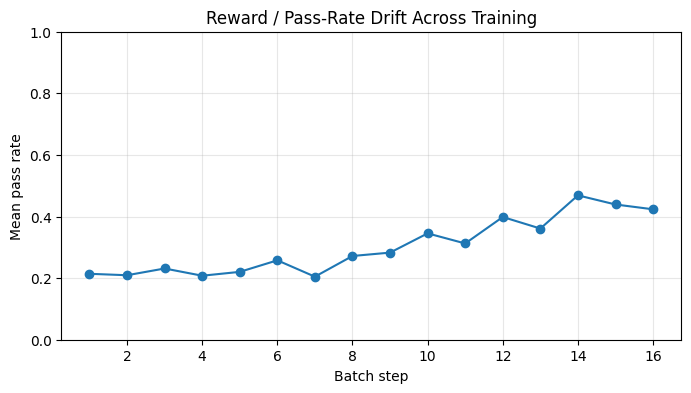

In [17]:
# Pass-rate drift
plt.figure(figsize=(8, 4))
plt.plot(
    batch_summary.index,
    batch_summary["mean_pass_rate"],
    marker="o"
)
plt.xlabel("Batch step")
plt.ylabel("Mean pass rate")
plt.title("Reward / Pass-Rate Drift Across Training")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.show()

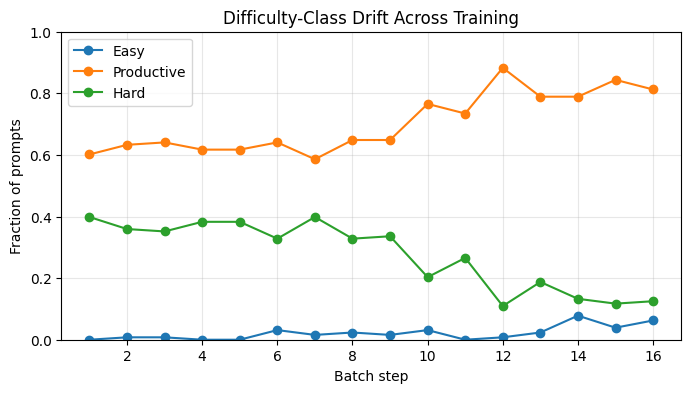

In [18]:
plt.figure(figsize=(8, 4))

plt.plot(
    batch_summary.index,
    batch_summary["Easy_frac"],
    marker="o",
    label="Easy"
)

plt.plot(
    batch_summary.index,
    batch_summary["Productive_frac"],
    marker="o",
    label="Productive"
)

plt.plot(
    batch_summary.index,
    batch_summary["Hard_frac"],
    marker="o",
    label="Hard"
)

plt.xlabel("Batch step")
plt.ylabel("Fraction of prompts")
plt.title("Difficulty-Class Drift Across Training")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 1. Summary
As training progresses, the model is getting more successful, fewer prompts are completely defeating it, and its answers are generally getting shorter.

--> mean response length decreases with training and accuracy increases.
One plausible interpretation is that the model becomes more efficient at solving these problems.


Conceptually one can guess: 

Early policy

prompt--> reason... --> wrong path--> reconsider--> more reasoning-->another attempt--> answer


Later policy

prompt-->recognize structure-->reason-->answer

==> Later batches exhibit shorter observed response lengths at the same time that rollout success increases.

# Important Week 4 insight

**Above data behaviour shows us evidence that our prediction target is not stationary**.

In week 3, we assumes that:

$$ \boxed{P(Y\mid X)} $$

is **reasonably stable**. where we try to predict Y which are our targets like length and difficulty given X (our prompt features).

Week 4 is showing us that this assumption is questionable.

A better description is:

$$ \boxed{P(Y\mid X,t)} $$

because the policy at time \(t\) matters.

# Reloading static week 3 predictor


In [19]:
import joblib

STATIC_PATH = (
    r"C:\Users\waqar\OneDrive\Desktop\Fellowship"
    r"\week3_static\week3_static_predictor.joblib"
)

static_bundle = joblib.load(STATIC_PATH)

FEATURE_COLS = static_bundle["feature_cols"]

length_scaler_static = static_bundle["length_scaler"]
length_model_static = static_bundle["length_model"]

difficulty_scaler_static = static_bundle["difficulty_scaler"]
difficulty_model_static = static_bundle["difficulty_model"]

print(type(length_model_static).__name__)
print(type(difficulty_model_static).__name__)
print(FEATURE_COLS)

Ridge
LogisticRegression
['n_chars', 'n_words', 'n_sentences', 'n_numbers', 'n_op_symbols', 'n_op_words', 'n_questions', 'n_commas', 'avg_word_len', 'n_hard_cues']


In [20]:
import re
import numpy as np
import pandas as pd

OP_WORDS = [
    "times","divided","multiply","product","sum","difference","remainder",
    "proportion","proportional","percent","ratio","average","per","total",
    "twice","half","double","triple","each","combined","increase","decrease",
]

HARD_CUES = [
    "remainder","proportion","proportional","percent","ratio","average","rate",
    "prove","derive","consecutive","profit","discount","interest",
]

NUMBER_RE = re.compile(r"\$?\d+(?:\.\d+)?%?")
OP_SYMBOL_RE = re.compile(r"[+\-*/=×÷]")

def extract(prompt):
    if pd.isna(prompt):
        prompt = ""

    prompt = str(prompt)
    text = prompt.strip()
    lower = text.lower()

    words = re.findall(r"\b\w+\b", text)
    sentences = [
        s for s in re.split(r"[.?!]+", text)
        if s.strip()
    ]

    return {
        "n_chars": len(text),
        "n_words": len(words),
        "n_sentences": len(sentences),
        "n_numbers": len(NUMBER_RE.findall(text)),
        "n_op_symbols": len(OP_SYMBOL_RE.findall(text)),
        "n_op_words": sum(lower.count(word) for word in OP_WORDS),
        "n_questions": text.count("?"),
        "n_commas": text.count(","),
        "avg_word_len": (
            float(np.mean([len(word) for word in words]))
            if words else 0.0
        ),
        "n_hard_cues": sum(lower.count(cue) for cue in HARD_CUES),
    }

def build_table(prompts):
    return pd.DataFrame(
        [extract(prompt) for prompt in prompts]
    )

In [22]:
# Extract Week 3-style features for every Week 4 prompt observation

X_static = build_table(
    prompt_trace["input"].tolist()
)

# Force the exact feature order stored in the frozen checkpoint
X_static = X_static[FEATURE_COLS].copy()

print("Shape:", X_static.shape)
print("\nColumns:")
print(X_static.columns.tolist())

print("\nMissing values:")
print(X_static.isna().sum())

display(X_static.head())

Shape: (2048, 10)

Columns:
['n_chars', 'n_words', 'n_sentences', 'n_numbers', 'n_op_symbols', 'n_op_words', 'n_questions', 'n_commas', 'avg_word_len', 'n_hard_cues']

Missing values:
n_chars         0
n_words         0
n_sentences     0
n_numbers       0
n_op_symbols    0
n_op_words      0
n_questions     0
n_commas        0
avg_word_len    0
n_hard_cues     0
dtype: int64


,n_chars,n_words,n_sentences,n_numbers,n_op_symbols,n_op_words,n_questions,n_commas,avg_word_len,n_hard_cues
0,339,55,5,4,0,4,0,2,4.945455,0
1,343,61,6,5,0,1,1,2,4.409836,0
2,289,52,4,4,1,2,1,2,4.346154,1
3,294,53,5,4,0,1,1,1,4.245283,0
4,342,61,7,5,0,1,1,5,4.327869,0


In [23]:
import numpy as np

# -------------------------
# Static length predictions
# -------------------------

X_static_len_scaled = length_scaler_static.transform(
    X_static
)

static_pred_len = length_model_static.predict(
    X_static_len_scaled
)

# -------------------------
# Static difficulty predictions
# -------------------------

X_static_diff_scaled = difficulty_scaler_static.transform(
    X_static
)

static_diff_prob = difficulty_model_static.predict_proba(
    X_static_diff_scaled
)

static_pred_diff = difficulty_model_static.predict(
    X_static_diff_scaled
)

# -------------------------
# Attach predictions
# -------------------------

prompt_trace["static_pred_len"] = static_pred_len

prompt_trace["static_prob_easy"] = static_diff_prob[:, 0]
prompt_trace["static_prob_productive"] = static_diff_prob[:, 1]
prompt_trace["static_prob_hard"] = static_diff_prob[:, 2]

prompt_trace["static_pred_difficulty"] = static_pred_diff

print("Length predictions:", static_pred_len.shape)
print("Difficulty probabilities:", static_diff_prob.shape)

display(
    prompt_trace[
        [
            "batch_step",
            "prompt_id",
            "mean_resp_len",
            "static_pred_len",
            "difficulty",
            "static_pred_difficulty",
            "static_prob_easy",
            "static_prob_productive",
            "static_prob_hard",
        ]
    ].head()
)

Length predictions: (2048,)
Difficulty probabilities: (2048, 3)


,batch_step,prompt_id,mean_resp_len,static_pred_len,difficulty,static_pred_difficulty,static_prob_easy,static_prob_productive,static_prob_hard
0,1,02a0d5cc-bd9f-4dd6-8906-79b9714021d5,1423.2,441.826119,1,1,0.003316,0.723409,0.273276
1,1,03d9b22f-128c-470d-8f14-e428ea341c31,387.8,544.435980,1,1,0.050830,0.508123,0.441048
2,1,06f16129-bf4b-43ad-8716-375b98c29508,1432.6,569.391208,1,2,0.000024,0.444265,0.555711
3,1,07606172-8b3a-4162-9fb5-744abbe59aa0,1031.6,542.559017,1,1,0.002362,0.518967,0.478672
4,1,0d7185a5-053e-47e9-9eb0-753afb9b20d4,296.8,585.373638,1,0,0.865514,0.057895,0.076592


In [24]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, brier_score_loss

rows = []

for batch, df_b in prompt_trace.groupby("batch_step"):

    # -------------------------
    # Length
    # -------------------------
    length_mae = mean_absolute_error(
        df_b["mean_resp_len"],
        df_b["static_pred_len"]
    )

    actual_mean_len = df_b["mean_resp_len"].mean()
    pred_mean_len = df_b["static_pred_len"].mean()

    # -------------------------
    # Difficulty targets
    # 0 = Easy
    # 1 = Productive
    # 2 = Hard
    # -------------------------

    y_easy = (df_b["difficulty"] == 0).astype(int)
    y_productive = (df_b["difficulty"] == 1).astype(int)
    y_hard = (df_b["difficulty"] == 2).astype(int)

    easy_brier = brier_score_loss(
        y_easy,
        df_b["static_prob_easy"]
    )

    productive_brier = brier_score_loss(
        y_productive,
        df_b["static_prob_productive"]
    )

    hard_brier = brier_score_loss(
        y_hard,
        df_b["static_prob_hard"]
    )

    rows.append({
        "batch_step": batch,

        "actual_mean_len": actual_mean_len,
        "pred_mean_len": pred_mean_len,
        "length_mae": length_mae,

        "actual_easy_frac": y_easy.mean(),
        "pred_easy_prob": df_b["static_prob_easy"].mean(),

        "actual_productive_frac": y_productive.mean(),
        "pred_productive_prob": df_b["static_prob_productive"].mean(),

        "actual_hard_frac": y_hard.mean(),
        "pred_hard_prob": df_b["static_prob_hard"].mean(),

        "easy_brier": easy_brier,
        "productive_brier": productive_brier,
        "hard_brier": hard_brier,
    })

static_batch_metrics = pd.DataFrame(rows).set_index("batch_step")

display(static_batch_metrics.round(3))

,actual_mean_len,pred_mean_len,length_mae,actual_easy_frac,pred_easy_prob,actual_productive_frac,pred_productive_prob,actual_hard_frac,pred_hard_prob,easy_brier,productive_brier,hard_brier
batch_step,,,,,,,,,,,,
1,963.841,556.413,486.246,0.000,0.076,0.602,0.469,0.398,0.455,0.037,0.254,0.234
2,875.252,555.141,414.487,0.008,0.088,0.633,0.465,0.359,0.447,0.064,0.309,0.263
3,841.138,553.857,379.958,0.008,0.049,0.641,0.492,0.352,0.459,0.038,0.251,0.253
4,840.991,558.998,371.850,0.000,0.091,0.617,0.452,0.383,0.457,0.052,0.284,0.236
5,937.039,553.167,466.598,0.000,0.109,0.617,0.454,0.383,0.437,0.072,0.281,0.273
6,839.109,555.771,380.120,0.031,0.073,0.641,0.475,0.328,0.451,0.061,0.272,0.232
7,831.795,553.598,398.174,0.016,0.055,0.586,0.486,0.398,0.459,0.039,0.261,0.256
8,915.588,557.418,439.614,0.023,0.054,0.648,0.464,0.328,0.482,0.043,0.259,0.240
9,884.973,557.835,424.353,0.016,0.082,0.648,0.466,0.336,0.452,0.065,0.267,0.232


# Observations
The Static length predictor is badly out-of-distribution from the beginning, but training drift happens to move the observed response-length distribution closer to its old Week 3 prediction.

In [25]:
from sklearn.metrics import roc_auc_score
import pandas as pd
import numpy as np

rows = []

for batch, df_b in prompt_trace.groupby("batch_step"):

    # Binary one-vs-rest targets
    y_productive = (df_b["difficulty"] == 1).astype(int)
    y_hard = (df_b["difficulty"] == 2).astype(int)

    # AUROC is only defined if both 0 and 1 exist
    productive_auc = (
        roc_auc_score(
            y_productive,
            df_b["static_prob_productive"]
        )
        if y_productive.nunique() == 2
        else np.nan
    )

    hard_auc = (
        roc_auc_score(
            y_hard,
            df_b["static_prob_hard"]
        )
        if y_hard.nunique() == 2
        else np.nan
    )

    rows.append({
        "batch_step": batch,
        "productive_auc": productive_auc,
        "hard_auc": hard_auc,
    })

static_auc_by_batch = (
    pd.DataFrame(rows)
    .set_index("batch_step")
)

display(static_auc_by_batch.round(3))

,productive_auc,hard_auc
batch_step,,
1,0.608,0.634
2,0.467,0.530
3,0.615,0.582
4,0.529,0.621
5,0.542,0.516
6,0.549,0.622
7,0.558,0.553
8,0.602,0.620
9,0.583,0.646


In [26]:
early_batches = [1, 2, 3, 4]
late_batches = [13, 14, 15, 16]

print("EARLY — batches 1-4")
print(
    static_auc_by_batch
    .loc[early_batches]
    .mean()
    .round(3)
)

print("\nLATE — batches 13-16")
print(
    static_auc_by_batch
    .loc[late_batches]
    .mean()
    .round(3)
)

EARLY — batches 1-4
productive_auc    0.555
hard_auc          0.592
dtype: float64

LATE — batches 13-16
productive_auc    0.578
hard_auc          0.539
dtype: float64


# Length:
badly shifted from the start.
MAE actually improves later because reality moves toward the old prediction

# Difficulty ranking:
weak early,
weak late

# Difficulty calibration:
clearly becomes stale as training distribution changes

# Periodic Refit replay

In [28]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LogisticRegression

REFIT_EVERY = 4

# Keep chronological order
periodic_trace = (
    prompt_trace
    .sort_values(["batch_step", "prompt_id"])
    .copy()
    .reset_index(drop=True)
)

# Same Week 3 features, in exactly the frozen order
X_periodic_all = build_table(
    periodic_trace["input"].tolist()
)[FEATURE_COLS].copy()

# Start from the frozen Week 3 models
current_len_scaler = length_scaler_static
current_len_model = length_model_static

current_diff_scaler = difficulty_scaler_static
current_diff_model = difficulty_model_static

results = []

for batch in sorted(periodic_trace["batch_step"].unique()):

    # -------------------------------------------------
    # 1. CURRENT BATCH
    # -------------------------------------------------
    batch_mask = periodic_trace["batch_step"] == batch
    batch_idx = np.where(batch_mask)[0]

    X_batch = X_periodic_all.iloc[batch_idx]

    # -------------------------------------------------
    # 2. PREDICT FIRST
    #    No current-batch outcomes used yet
    # -------------------------------------------------

    # Length
    X_len_scaled = current_len_scaler.transform(X_batch)

    pred_len = current_len_model.predict(
        X_len_scaled
    )

    # Difficulty
    X_diff_scaled = current_diff_scaler.transform(X_batch)

    raw_prob = current_diff_model.predict_proba(
        X_diff_scaled
    )

    # Robustly place probabilities into:
    # column 0 = Easy
    # column 1 = Productive
    # column 2 = Hard
    diff_prob = np.zeros((len(X_batch), 3))

    for j, cls in enumerate(current_diff_model.classes_):
        diff_prob[:, int(cls)] = raw_prob[:, j]

    pred_diff = np.argmax(diff_prob, axis=1)

    # Save predictions
    for local_i, row_idx in enumerate(batch_idx):

        results.append({
            "row_idx": row_idx,
            "batch_step": batch,

            "periodic_pred_len":
                pred_len[local_i],

            "periodic_prob_easy":
                diff_prob[local_i, 0],

            "periodic_prob_productive":
                diff_prob[local_i, 1],

            "periodic_prob_hard":
                diff_prob[local_i, 2],

            "periodic_pred_difficulty":
                pred_diff[local_i],
        })

    # -------------------------------------------------
    # 3. OBSERVE CURRENT BATCH
    # -------------------------------------------------
    # At this point its true outcomes are allowed
    # into history.

    # -------------------------------------------------
    # 4. REFIT AFTER every 4th observed batch
    #    except after final batch, where it isn't needed
    # -------------------------------------------------

    if (
        batch % REFIT_EVERY == 0
        and batch < periodic_trace["batch_step"].max()
    ):

        history_mask = (
            periodic_trace["batch_step"] <= batch
        )

        history_idx = np.where(history_mask)[0]

        X_hist = X_periodic_all.iloc[history_idx]

        y_len_hist = (
            periodic_trace.loc[
                history_mask,
                "mean_resp_len"
            ]
            .to_numpy()
        )

        y_diff_hist = (
            periodic_trace.loc[
                history_mask,
                "difficulty"
            ]
            .to_numpy()
        )

        # -------------------------
        # Refit length head
        # -------------------------

        current_len_scaler = StandardScaler()

        X_hist_len_scaled = (
            current_len_scaler
            .fit_transform(X_hist)
        )

        current_len_model = Ridge(
            alpha=1.0
        )

        current_len_model.fit(
            X_hist_len_scaled,
            y_len_hist
        )

        # -------------------------
        # Refit difficulty head
        # -------------------------

        current_diff_scaler = StandardScaler()

        X_hist_diff_scaled = (
            current_diff_scaler
            .fit_transform(X_hist)
        )

        current_diff_model = LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=42
        )

        current_diff_model.fit(
            X_hist_diff_scaled,
            y_diff_hist
        )

        print(
            f"Refit after batch {batch}: "
            f"{len(history_idx)} prompt observations"
        )

Refit after batch 4: 512 prompt observations
Refit after batch 8: 1024 prompt observations
Refit after batch 12: 1536 prompt observations


In [29]:
periodic_results = (
    pd.DataFrame(results)
    .sort_values("row_idx")
    .reset_index(drop=True)
)

print("Periodic result shape:", periodic_results.shape)

# Attach predictions
periodic_trace[
    [
        "periodic_pred_len",
        "periodic_prob_easy",
        "periodic_prob_productive",
        "periodic_prob_hard",
        "periodic_pred_difficulty",
    ]
] = periodic_results[
    [
        "periodic_pred_len",
        "periodic_prob_easy",
        "periodic_prob_productive",
        "periodic_prob_hard",
        "periodic_pred_difficulty",
    ]
].to_numpy()

print("\nMissing predictions:")
print(
    periodic_trace[
        [
            "periodic_pred_len",
            "periodic_prob_easy",
            "periodic_prob_productive",
            "periodic_prob_hard",
        ]
    ].isna().sum()
)

display(
    periodic_trace[
        [
            "batch_step",
            "mean_resp_len",
            "static_pred_len",
            "periodic_pred_len",
            "difficulty",
            "static_prob_productive",
            "periodic_prob_productive",
            "static_prob_hard",
            "periodic_prob_hard",
        ]
    ].head()
)

Periodic result shape: (2048, 7)

Missing predictions:
periodic_pred_len           0
periodic_prob_easy          0
periodic_prob_productive    0
periodic_prob_hard          0
dtype: int64


,batch_step,mean_resp_len,static_pred_len,periodic_pred_len,difficulty,static_prob_productive,periodic_prob_productive,static_prob_hard,periodic_prob_hard
0,1,1423.2,441.826119,441.826119,1,0.723409,0.723409,0.273276,0.273276
1,1,387.8,544.435980,544.435980,1,0.508123,0.508123,0.441048,0.441048
2,1,1432.6,569.391208,569.391208,1,0.444265,0.444265,0.555711,0.555711
3,1,1031.6,542.559017,542.559017,1,0.518967,0.518967,0.478672,0.478672
4,1,296.8,585.373638,585.373638,1,0.057895,0.057895,0.076592,0.076592


In [30]:
from sklearn.metrics import mean_absolute_error, brier_score_loss, roc_auc_score
import numpy as np
import pandas as pd

rows = []

for batch, df_b in periodic_trace.groupby("batch_step"):

    # -------------------------
    # Length MAE
    # -------------------------
    static_mae = mean_absolute_error(
        df_b["mean_resp_len"],
        df_b["static_pred_len"]
    )

    periodic_mae = mean_absolute_error(
        df_b["mean_resp_len"],
        df_b["periodic_pred_len"]
    )

    # -------------------------
    # Binary difficulty targets
    # -------------------------
    y_productive = (df_b["difficulty"] == 1).astype(int)
    y_hard = (df_b["difficulty"] == 2).astype(int)

    # -------------------------
    # Brier scores
    # -------------------------
    static_prod_brier = brier_score_loss(
        y_productive,
        df_b["static_prob_productive"]
    )

    periodic_prod_brier = brier_score_loss(
        y_productive,
        df_b["periodic_prob_productive"]
    )

    static_hard_brier = brier_score_loss(
        y_hard,
        df_b["static_prob_hard"]
    )

    periodic_hard_brier = brier_score_loss(
        y_hard,
        df_b["periodic_prob_hard"]
    )

    # -------------------------
    # AUROC
    # -------------------------
    if y_productive.nunique() == 2:
        static_prod_auc = roc_auc_score(
            y_productive,
            df_b["static_prob_productive"]
        )

        periodic_prod_auc = roc_auc_score(
            y_productive,
            df_b["periodic_prob_productive"]
        )
    else:
        static_prod_auc = np.nan
        periodic_prod_auc = np.nan

    if y_hard.nunique() == 2:
        static_hard_auc = roc_auc_score(
            y_hard,
            df_b["static_prob_hard"]
        )

        periodic_hard_auc = roc_auc_score(
            y_hard,
            df_b["periodic_prob_hard"]
        )
    else:
        static_hard_auc = np.nan
        periodic_hard_auc = np.nan

    rows.append({
        "batch_step": batch,

        "static_mae": static_mae,
        "periodic_mae": periodic_mae,

        "static_prod_brier": static_prod_brier,
        "periodic_prod_brier": periodic_prod_brier,

        "static_hard_brier": static_hard_brier,
        "periodic_hard_brier": periodic_hard_brier,

        "static_prod_auc": static_prod_auc,
        "periodic_prod_auc": periodic_prod_auc,

        "static_hard_auc": static_hard_auc,
        "periodic_hard_auc": periodic_hard_auc,
    })

comparison = (
    pd.DataFrame(rows)
    .set_index("batch_step")
)

display(comparison.round(3))

,static_mae,periodic_mae,static_prod_brier,periodic_prod_brier,static_hard_brier,periodic_hard_brier,static_prod_auc,periodic_prod_auc,static_hard_auc,periodic_hard_auc
batch_step,,,,,,,,,,
1,486.246,486.246,0.254,0.254,0.234,0.234,0.608,0.608,0.634,0.634
2,414.487,414.487,0.309,0.309,0.263,0.263,0.467,0.467,0.530,0.530
3,379.958,379.958,0.251,0.251,0.253,0.253,0.615,0.615,0.582,0.582
4,371.850,371.850,0.284,0.284,0.236,0.236,0.529,0.529,0.621,0.621
5,466.598,364.643,0.281,0.258,0.273,0.273,0.542,0.610,0.516,0.519
6,380.120,354.445,0.272,0.289,0.232,0.235,0.549,0.518,0.622,0.576
7,398.174,350.598,0.261,0.256,0.256,0.241,0.558,0.600,0.553,0.613
8,439.614,364.391,0.259,0.302,0.240,0.232,0.602,0.467,0.620,0.620
9,424.353,362.313,0.267,0.333,0.232,0.211,0.583,0.495,0.646,0.652


## the EWMA replay

Can a recency-weighted predictor follow the moving distribution better than a cumulative refit that keeps carrying old-policy data forever?

In [31]:
import numpy as np
import pandas as pd

ALPHA = 0.10

ewma_trace = (
    prompt_trace
    .sort_values(["batch_step", "prompt_id"])
    .copy()
    .reset_index(drop=True)
)

# -------------------------------------------------
# Initial state
# -------------------------------------------------

# Length drift correction starts at zero:
# before seeing Week 4, EWMA == Static.
ewma_len_bias = 0.0
ewma_len_var = 0.0

# Week 3 difficulty prior:
# Easy=4, Productive=218, Hard=162 out of 384
base_class_prior = np.array([
    4 / 384,
    218 / 384,
    162 / 384
], dtype=float)

ewma_class_freq = base_class_prior.copy()

ewma_results = []

for batch in sorted(ewma_trace["batch_step"].unique()):

    df_b = ewma_trace[
        ewma_trace["batch_step"] == batch
    ].copy()

    # =============================================
    # 1. PREDICT FIRST
    # =============================================

    # -------------------------
    # Length
    # -------------------------
    ewma_pred_len = (
        df_b["static_pred_len"].to_numpy()
        + ewma_len_bias
    )

    # -------------------------
    # Difficulty
    # -------------------------
    static_probs = df_b[
        [
            "static_prob_easy",
            "static_prob_productive",
            "static_prob_hard",
        ]
    ].to_numpy()

    # Adjust Static probabilities for the
    # current EWMA-estimated class distribution.
    prior_ratio = (
        ewma_class_freq
        / np.clip(base_class_prior, 1e-8, None)
    )

    adjusted_probs = static_probs * prior_ratio

    adjusted_probs = (
        adjusted_probs
        / adjusted_probs.sum(axis=1, keepdims=True)
    )

    ewma_pred_diff = np.argmax(
        adjusted_probs,
        axis=1
    )

    # Store predictions made BEFORE observation
    for i, (_, row) in enumerate(df_b.iterrows()):

        ewma_results.append({
            "batch_step": batch,
            "prompt_id": row["prompt_id"],

            "ewma_pred_len":
                ewma_pred_len[i],

            "ewma_prob_easy":
                adjusted_probs[i, 0],

            "ewma_prob_productive":
                adjusted_probs[i, 1],

            "ewma_prob_hard":
                adjusted_probs[i, 2],

            "ewma_pred_difficulty":
                ewma_pred_diff[i],
        })

    # =============================================
    # 2. OBSERVE CURRENT BATCH
    # =============================================

    # Length residual:
    # positive = Static underestimated length
    residuals = (
        df_b["mean_resp_len"].to_numpy()
        - df_b["static_pred_len"].to_numpy()
    )

    batch_residual_mean = residuals.mean()
    batch_residual_var = residuals.var(ddof=0)

    # Update length EWMA
    ewma_len_bias = (
        (1 - ALPHA) * ewma_len_bias
        + ALPHA * batch_residual_mean
    )

    ewma_len_var = (
        (1 - ALPHA) * ewma_len_var
        + ALPHA * batch_residual_var
    )

    # ---------------------------------------------
    # Difficulty class-frequency update
    # ---------------------------------------------

    batch_class_freq = np.array([
        (df_b["difficulty"] == 0).mean(),
        (df_b["difficulty"] == 1).mean(),
        (df_b["difficulty"] == 2).mean(),
    ])

    ewma_class_freq = (
        (1 - ALPHA) * ewma_class_freq
        + ALPHA * batch_class_freq
    )

    print(
        f"After batch {batch:2d} | "
        f"length bias={ewma_len_bias:7.1f} | "
        f"class freq="
        f"[{ewma_class_freq[0]:.3f}, "
        f"{ewma_class_freq[1]:.3f}, "
        f"{ewma_class_freq[2]:.3f}]"
    )

After batch  1 | length bias=   40.7 | class freq=[0.009, 0.571, 0.420]
After batch  2 | length bias=   68.7 | class freq=[0.009, 0.577, 0.414]
After batch  3 | length bias=   90.5 | class freq=[0.009, 0.584, 0.407]
After batch  4 | length bias=  109.7 | class freq=[0.008, 0.587, 0.405]
After batch  5 | length bias=  137.1 | class freq=[0.007, 0.590, 0.403]
After batch  6 | length bias=  151.7 | class freq=[0.010, 0.595, 0.395]
After batch  7 | length bias=  164.4 | class freq=[0.010, 0.594, 0.396]
After batch  8 | length bias=  183.8 | class freq=[0.012, 0.600, 0.389]
After batch  9 | length bias=  198.1 | class freq=[0.012, 0.604, 0.384]
After batch 10 | length bias=  201.8 | class freq=[0.014, 0.621, 0.365]
After batch 11 | length bias=  207.3 | class freq=[0.013, 0.632, 0.355]
After batch 12 | length bias=  200.4 | class freq=[0.012, 0.657, 0.331]
After batch 13 | length bias=  193.9 | class freq=[0.013, 0.670, 0.317]
After batch 14 | length bias=  184.1 | class freq=[0.020, 0.682,

In [32]:
ewma_results_df = pd.DataFrame(ewma_results)

print("EWMA result shape:", ewma_results_df.shape)

# Same chronological ordering used during replay
ewma_results_df = (
    ewma_results_df
    .sort_values(["batch_step", "prompt_id"])
    .reset_index(drop=True)
)

ewma_trace = (
    ewma_trace
    .sort_values(["batch_step", "prompt_id"])
    .reset_index(drop=True)
)

# Attach predictions
ewma_trace[
    [
        "ewma_pred_len",
        "ewma_prob_easy",
        "ewma_prob_productive",
        "ewma_prob_hard",
        "ewma_pred_difficulty",
    ]
] = ewma_results_df[
    [
        "ewma_pred_len",
        "ewma_prob_easy",
        "ewma_prob_productive",
        "ewma_prob_hard",
        "ewma_pred_difficulty",
    ]
].to_numpy()

print("\nMissing EWMA predictions:")
print(
    ewma_trace[
        [
            "ewma_pred_len",
            "ewma_prob_easy",
            "ewma_prob_productive",
            "ewma_prob_hard",
        ]
    ].isna().sum()
)

display(
    ewma_trace[
        [
            "batch_step",
            "mean_resp_len",
            "static_pred_len",
            "ewma_pred_len",
            "difficulty",
            "static_prob_productive",
            "ewma_prob_productive",
            "static_prob_hard",
            "ewma_prob_hard",
        ]
    ].head()
)

EWMA result shape: (2048, 7)

Missing EWMA predictions:
ewma_pred_len           0
ewma_prob_easy          0
ewma_prob_productive    0
ewma_prob_hard          0
dtype: int64


,batch_step,mean_resp_len,static_pred_len,ewma_pred_len,difficulty,static_prob_productive,ewma_prob_productive,static_prob_hard,ewma_prob_hard
0,1,1423.2,441.826119,441.826119,1,0.723409,0.723409,0.273276,0.273276
1,1,387.8,544.435980,544.435980,1,0.508123,0.508123,0.441048,0.441048
2,1,1432.6,569.391208,569.391208,1,0.444265,0.444265,0.555711,0.555711
3,1,1031.6,542.559017,542.559017,1,0.518967,0.518967,0.478672,0.478672
4,1,296.8,585.373638,585.373638,1,0.057895,0.057895,0.076592,0.076592


# Static vs Periodic Refit vs EWMA

In [33]:
comparison_trace = ewma_trace.merge(
    periodic_trace[
        [
            "batch_step",
            "prompt_id",
            "periodic_pred_len",
            "periodic_prob_easy",
            "periodic_prob_productive",
            "periodic_prob_hard",
            "periodic_pred_difficulty",
        ]
    ],
    on=["batch_step", "prompt_id"],
    how="left",
    validate="one_to_one"
)

print("Shape:", comparison_trace.shape)

print("\nMissing periodic predictions:")
print(
    comparison_trace[
        [
            "periodic_pred_len",
            "periodic_prob_productive",
            "periodic_prob_hard",
        ]
    ].isna().sum()
)

Shape: (2048, 23)

Missing periodic predictions:
periodic_pred_len           0
periodic_prob_productive    0
periodic_prob_hard          0
dtype: int64


In [34]:
from sklearn.metrics import (
    mean_absolute_error,
    brier_score_loss,
    roc_auc_score
)

rows = []

for batch, df_b in comparison_trace.groupby("batch_step"):

    y_prod = (df_b["difficulty"] == 1).astype(int)
    y_hard = (df_b["difficulty"] == 2).astype(int)

    row = {"batch_step": batch}

    for strategy in ["static", "periodic", "ewma"]:

        # Length
        row[f"{strategy}_mae"] = mean_absolute_error(
            df_b["mean_resp_len"],
            df_b[f"{strategy}_pred_len"]
        )

        # Productive calibration
        row[f"{strategy}_prod_brier"] = brier_score_loss(
            y_prod,
            df_b[f"{strategy}_prob_productive"]
        )

        # Hard calibration
        row[f"{strategy}_hard_brier"] = brier_score_loss(
            y_hard,
            df_b[f"{strategy}_prob_hard"]
        )

        # Productive AUROC
        row[f"{strategy}_prod_auc"] = (
            roc_auc_score(
                y_prod,
                df_b[f"{strategy}_prob_productive"]
            )
            if y_prod.nunique() == 2
            else np.nan
        )

        # Hard AUROC
        row[f"{strategy}_hard_auc"] = (
            roc_auc_score(
                y_hard,
                df_b[f"{strategy}_prob_hard"]
            )
            if y_hard.nunique() == 2
            else np.nan
        )

    rows.append(row)

three_way_metrics = (
    pd.DataFrame(rows)
    .set_index("batch_step")
)

display(three_way_metrics.round(3))

,static_mae,static_prod_brier,static_hard_brier,static_prod_auc,static_hard_auc,periodic_mae,periodic_prod_brier,periodic_hard_brier,periodic_prod_auc,periodic_hard_auc,ewma_mae,ewma_prod_brier,ewma_hard_brier,ewma_prod_auc,ewma_hard_auc
batch_step,,,,,,,,,,,,,,,
1,486.246,0.254,0.234,0.608,0.634,486.246,0.254,0.234,0.608,0.634,486.246,0.254,0.234,0.608,0.634
2,414.487,0.309,0.263,0.467,0.530,414.487,0.309,0.263,0.467,0.530,397.140,0.307,0.262,0.469,0.532
3,379.958,0.251,0.253,0.615,0.582,379.958,0.251,0.253,0.615,0.582,351.364,0.248,0.251,0.616,0.583
4,371.850,0.284,0.236,0.529,0.621,371.850,0.284,0.236,0.529,0.621,333.861,0.279,0.234,0.536,0.619
5,466.598,0.281,0.273,0.542,0.516,364.643,0.258,0.273,0.610,0.519,417.947,0.275,0.270,0.544,0.515
6,380.120,0.272,0.232,0.549,0.622,354.445,0.289,0.235,0.518,0.576,346.408,0.263,0.228,0.552,0.620
7,398.174,0.261,0.256,0.558,0.553,350.598,0.256,0.241,0.600,0.613,358.688,0.257,0.253,0.558,0.554
8,439.614,0.259,0.240,0.602,0.620,364.391,0.302,0.232,0.467,0.620,376.089,0.251,0.233,0.602,0.620
9,424.353,0.267,0.232,0.583,0.646,362.313,0.333,0.211,0.495,0.652,371.327,0.261,0.225,0.579,0.646


In [35]:
summary_rows = []

windows = {
    "overall_1_16": list(range(1, 17)),
    "early_1_4": [1, 2, 3, 4],
    "late_13_16": [13, 14, 15, 16],
}

for window_name, batches in windows.items():
    m = three_way_metrics.loc[batches].mean()

    summary_rows.append({
        "window": window_name,

        "static_mae": m["static_mae"],
        "periodic_mae": m["periodic_mae"],
        "ewma_mae": m["ewma_mae"],

        "static_prod_brier": m["static_prod_brier"],
        "periodic_prod_brier": m["periodic_prod_brier"],
        "ewma_prod_brier": m["ewma_prod_brier"],

        "static_hard_brier": m["static_hard_brier"],
        "periodic_hard_brier": m["periodic_hard_brier"],
        "ewma_hard_brier": m["ewma_hard_brier"],

        "static_prod_auc": m["static_prod_auc"],
        "periodic_prod_auc": m["periodic_prod_auc"],
        "ewma_prod_auc": m["ewma_prod_auc"],

        "static_hard_auc": m["static_hard_auc"],
        "periodic_hard_auc": m["periodic_hard_auc"],
        "ewma_hard_auc": m["ewma_hard_auc"],
    })

winner_summary = pd.DataFrame(summary_rows).set_index("window")

display(winner_summary.round(3))

,static_mae,periodic_mae,ewma_mae,static_prod_brier,periodic_prod_brier,ewma_prod_brier,static_hard_brier,periodic_hard_brier,ewma_hard_brier,static_prod_auc,periodic_prod_auc,ewma_prod_auc,static_hard_auc,periodic_hard_auc,ewma_hard_auc
window,,,,,,,,,,,,,,,
overall_1_16,375.735,366.982,355.318,0.271,0.322,0.252,0.241,0.212,0.219,0.576,0.520,0.574,0.585,0.597,0.585
early_1_4,413.135,413.135,392.153,0.274,0.274,0.272,0.246,0.246,0.245,0.555,0.555,0.557,0.592,0.592,0.592
late_13_16,305.390,341.102,312.863,0.272,0.382,0.223,0.237,0.164,0.175,0.578,0.461,0.570,0.539,0.589,0.540


In [36]:
overall = winner_summary.loc["overall_1_16"]
late = winner_summary.loc["late_13_16"]

print("=== OVERALL EWMA vs STATIC ===")

print(
    "Length MAE improvement:",
    round(
        100 * (overall["static_mae"] - overall["ewma_mae"])
        / overall["static_mae"],
        1
    ),
    "%"
)

print(
    "Productive Brier improvement:",
    round(
        100 * (
            overall["static_prod_brier"]
            - overall["ewma_prod_brier"]
        )
        / overall["static_prod_brier"],
        1
    ),
    "%"
)

print(
    "Hard Brier improvement:",
    round(
        100 * (
            overall["static_hard_brier"]
            - overall["ewma_hard_brier"]
        )
        / overall["static_hard_brier"],
        1
    ),
    "%"
)

print("\n=== LATE EWMA vs STATIC ===")

print(
    "Productive Brier improvement:",
    round(
        100 * (
            late["static_prod_brier"]
            - late["ewma_prod_brier"]
        )
        / late["static_prod_brier"],
        1
    ),
    "%"
)

print(
    "Hard Brier improvement:",
    round(
        100 * (
            late["static_hard_brier"]
            - late["ewma_hard_brier"]
        )
        / late["static_hard_brier"],
        1
    ),
    "%"
)

=== OVERALL EWMA vs STATIC ===
Length MAE improvement: 5.4 %
Productive Brier improvement: 7.1 %
Hard Brier improvement: 9.2 %

=== LATE EWMA vs STATIC ===
Productive Brier improvement: 17.9 %
Hard Brier improvement: 26.1 %


# EWMA is the provisional winner on the available short development trace. The final strategy selection must be confirmed on the required long chronological trace.

In [37]:
import hashlib
import json

def ewma_state_hash(
    alpha,
    length_bias,
    length_var,
    class_freq
):
    state = {
        "alpha": float(alpha),
        "length_bias": float(length_bias),
        "length_var": float(length_var),
        "class_freq": [float(x) for x in class_freq],
    }

    payload = json.dumps(
        state,
        sort_keys=True,
        separators=(",", ":")
    ).encode("utf-8")

    return hashlib.sha256(payload).hexdigest()


final_ewma_hash = ewma_state_hash(
    ALPHA,
    ewma_len_bias,
    ewma_len_var,
    ewma_class_freq
)

print("EWMA state hash:")
print(final_ewma_hash)

EWMA state hash:
ec5393677a1dd71538c2d76faf163fdaa087365a3cabc162c67028bcb940e33b


In [38]:
import hashlib
import json

EWMA_STATE_VERSION = "ewma-v1"

def ewma_state_hash(
    alpha,
    length_bias,
    length_var,
    class_freq,
    n_updates,
    version=EWMA_STATE_VERSION,
):
    state = {
        "version": str(version),
        "alpha": float(alpha),
        "length_bias": float(length_bias),
        "length_var": float(length_var),
        "class_freq": [float(x) for x in class_freq],
        "n_updates": int(n_updates),
    }

    payload = json.dumps(
        state,
        sort_keys=True,
        separators=(",", ":")
    ).encode("utf-8")

    return hashlib.sha256(payload).hexdigest()


ewma_n_updates = int(
    ewma_trace["batch_step"].nunique()
)

final_ewma_hash_v1 = ewma_state_hash(
    alpha=ALPHA,
    length_bias=ewma_len_bias,
    length_var=ewma_len_var,
    class_freq=ewma_class_freq,
    n_updates=ewma_n_updates,
)

print("Version:", EWMA_STATE_VERSION)
print("Updates:", ewma_n_updates)
print("State hash:", final_ewma_hash_v1)

# Stability check
same_hash = ewma_state_hash(
    ALPHA,
    ewma_len_bias,
    ewma_len_var,
    ewma_class_freq,
    ewma_n_updates,
)

# Mutation check
changed_hash = ewma_state_hash(
    ALPHA,
    ewma_len_bias + 0.001,
    ewma_len_var,
    ewma_class_freq,
    ewma_n_updates,
)

print("\nStable:", final_ewma_hash_v1 == same_hash)
print("Changes on update:", final_ewma_hash_v1 != changed_hash)

Version: ewma-v1
Updates: 16
State hash: 3790380e1e1b30c5a23db03667cf21fcfe6dddaf64c67604a418fcf04df32945

Stable: True
Changes on update: True


# uncertainty + fallback

In [39]:
import numpy as np

# --------------------------------------------
# EWMA difficulty uncertainty
# normalized entropy in [0, 1]
# --------------------------------------------

P = ewma_trace[
    [
        "ewma_prob_easy",
        "ewma_prob_productive",
        "ewma_prob_hard",
    ]
].to_numpy()

P = np.clip(P, 1e-12, 1.0)

ewma_uncertainty = (
    -(P * np.log(P)).sum(axis=1)
    / np.log(3)
)

ewma_trace["ewma_uncertainty"] = ewma_uncertainty

print("Uncertainty range:")
print(
    round(ewma_uncertainty.min(), 4),
    "->",
    round(ewma_uncertainty.max(), 4)
)

print("Any negative?",
      bool((ewma_uncertainty < 0).any()))

# --------------------------------------------
# Calibrate threshold ONLY on early half
# batches 1-8
# --------------------------------------------

cal_mask = ewma_trace["batch_step"] <= 8
test_mask = ewma_trace["batch_step"] >= 9

cal_scores = ewma_trace.loc[
    cal_mask,
    "ewma_uncertainty"
].to_numpy()

UNCERTAINTY_THRESHOLD = np.quantile(
    cal_scores,
    0.95,
    method="higher"
)

# High uncertainty => fallback
ewma_trace["fallback"] = (
    ewma_trace["ewma_uncertainty"]
    > UNCERTAINTY_THRESHOLD
)

early_rate = (
    ewma_trace.loc[cal_mask, "fallback"].mean()
)

late_rate = (
    ewma_trace.loc[test_mask, "fallback"].mean()
)

overall_rate = ewma_trace["fallback"].mean()

print("\nThreshold:",
      round(UNCERTAINTY_THRESHOLD, 4))

print(
    "Early fallback rate:",
    round(100 * early_rate, 2),
    "%"
)

print(
    "Late fallback rate:",
    round(100 * late_rate, 2),
    "%"
)

print(
    "Overall fallback rate:",
    round(100 * overall_rate, 2),
    "%"
)

Uncertainty range:
0.0064 -> 0.9993
Any negative? False

Threshold: 0.9315
Early fallback rate: 4.98 %
Late fallback rate: 4.0 %
Overall fallback rate: 4.49 %


# The <5% fallback requirement and EWMA winner still need confirmation on the required long chronological trace.

In [40]:
import numpy as np

MIN_HISTORY_STEPS = 30

# Frozen Week 2/3 training-set mean response length
COLD_START_LENGTH = 556.992

# Safe difficulty prior during cold start
COLD_START_DIFFICULTY_PROBS = np.array([
    1/3,   # Easy
    1/3,   # Productive
    1/3,   # Hard
])


def cold_start_prediction(n_history_steps):
    """
    Safe predictor output before enough online history exists.
    """

    cold_start = n_history_steps < MIN_HISTORY_STEPS

    if cold_start:
        return {
            "predicted_response_length": COLD_START_LENGTH,
            "difficulty_probs": COLD_START_DIFFICULTY_PROBS.copy(),
            "predicted_difficulty": None,

            # Maximum uncertainty for uniform 3-class distribution
            "uncertainty": 1.0,

            "cold_start": True,

            # Critical scheduler behavior:
            # cold start must NEVER cause a prompt to be skipped.
            "allow_skip": False,
        }

    return {
        "predicted_response_length": None,
        "difficulty_probs": None,
        "predicted_difficulty": None,
        "uncertainty": None,
        "cold_start": False,
        "allow_skip": True,
    }


# Quick sanity checks
for n in [0, 10, 29, 30, 50]:
    print(n, cold_start_prediction(n))

0 {'predicted_response_length': 556.992, 'difficulty_probs': array([0.33333333, 0.33333333, 0.33333333]), 'predicted_difficulty': None, 'uncertainty': 1.0, 'cold_start': True, 'allow_skip': False}
10 {'predicted_response_length': 556.992, 'difficulty_probs': array([0.33333333, 0.33333333, 0.33333333]), 'predicted_difficulty': None, 'uncertainty': 1.0, 'cold_start': True, 'allow_skip': False}
29 {'predicted_response_length': 556.992, 'difficulty_probs': array([0.33333333, 0.33333333, 0.33333333]), 'predicted_difficulty': None, 'uncertainty': 1.0, 'cold_start': True, 'allow_skip': False}
30 {'predicted_response_length': None, 'difficulty_probs': None, 'predicted_difficulty': None, 'uncertainty': None, 'cold_start': False, 'allow_skip': True}
50 {'predicted_response_length': None, 'difficulty_probs': None, 'predicted_difficulty': None, 'uncertainty': None, 'cold_start': False, 'allow_skip': True}


In [45]:
import hashlib
import json
import numpy as np
import pandas as pd


class EWMAPredictorV2:
    """
    DUET Week 4 online predictor.

    Strategy:
        Frozen Week 3 content predictor
        + EWMA online drift correction

    Leakage rule:
        predict(batch_t)
        -> observe outcomes
        -> update(batch_t)
    """

    VERSION = "ewma-v1"

    def __init__(
        self,
        static_bundle,
        feature_builder,
        alpha=0.10,
        min_history_steps=30,
        cold_start_length=556.992,
        base_class_prior=(4/384, 218/384, 162/384),
        uncertainty_threshold=0.9315,
    ):
        # -------------------------
        # Configuration
        # -------------------------

        self.alpha = float(alpha)
        self.min_history_steps = int(min_history_steps)
        self.cold_start_length = float(cold_start_length)
        self.uncertainty_threshold = float(
            uncertainty_threshold
        )

        self.feature_builder = feature_builder
        self.feature_cols = list(
            static_bundle["feature_cols"]
        )

        # -------------------------
        # Frozen Week 3 models
        # -------------------------

        self.length_scaler = (
            static_bundle["length_scaler"]
        )

        self.length_model = (
            static_bundle["length_model"]
        )

        self.difficulty_scaler = (
            static_bundle["difficulty_scaler"]
        )

        self.difficulty_model = (
            static_bundle["difficulty_model"]
        )

        # -------------------------
        # Frozen Week 3 prior
        #
        # 0 = Easy
        # 1 = Productive
        # 2 = Hard
        # -------------------------

        self.base_class_prior = np.asarray(
            base_class_prior,
            dtype=float,
        )

        # -------------------------
        # Mutable EWMA state
        # -------------------------

        self.length_bias = 0.0
        self.length_var = 0.0

        self.class_freq = (
            self.base_class_prior.copy()
        )

        # Number of completed chronological
        # training batches observed
        self.n_history_steps = 0


    # =================================================
    # FEATURE EXTRACTION
    # =================================================

    def _features(self, prompts):
        """
        Build the feature matrix expected by
        the frozen Week 3 models.
        """

        prompts = list(prompts)

        X = self.feature_builder(prompts)

        return X[
            self.feature_cols
        ].copy()


    # =================================================
    # FROZEN WEEK 3 PREDICTIONS
    # =================================================

    def _static_predictions(self, prompts):
        """
        Run frozen Week 3 length and difficulty heads.

        Returns:
            static_len: shape (n,)
            static_probs: shape (n, 3)
        """

        X = self._features(prompts)

        # -------------------------
        # Length
        # -------------------------

        X_len = self.length_scaler.transform(X)

        static_len = self.length_model.predict(
            X_len
        )

        # -------------------------
        # Difficulty
        # -------------------------

        X_diff = (
            self.difficulty_scaler.transform(X)
        )

        raw_prob = (
            self.difficulty_model.predict_proba(
                X_diff
            )
        )

        # Explicit class alignment:
        # col 0 = Easy
        # col 1 = Productive
        # col 2 = Hard

        probs = np.zeros(
            (len(X), 3),
            dtype=float,
        )

        for j, cls in enumerate(
            self.difficulty_model.classes_
        ):
            probs[:, int(cls)] = raw_prob[:, j]

        return static_len, probs


    # =================================================
    # UNCERTAINTY
    # =================================================

    @staticmethod
    def _entropy(probs):
        """
        Normalized categorical entropy.

        Range:
            0 = confident
            1 = maximally uncertain
        """

        probs = np.clip(
            np.asarray(
                probs,
                dtype=float,
            ),
            1e-12,
            1.0,
        )

        return (
            -(probs * np.log(probs)).sum(axis=1)
            / np.log(3)
        )


    # =================================================
    # PREDICT
    # =================================================

    def predict(self, prompts):
        """
        Predict without modifying predictor state.
        """

        prompts = list(prompts)
        n = len(prompts)

        cold_start = (
            self.n_history_steps
            < self.min_history_steps
        )

        # -------------------------
        # Cold start
        # -------------------------

        if cold_start:

            pred_len = np.full(
                n,
                self.cold_start_length,
                dtype=float,
            )

            # Safe uniform difficulty prior
            probs = np.full(
                (n, 3),
                1 / 3,
                dtype=float,
            )

            pred_diff = np.array(
                [None] * n,
                dtype=object,
            )

        # -------------------------
        # Online EWMA mode
        # -------------------------

        else:

            static_len, static_probs = (
                self._static_predictions(prompts)
            )

            # Length drift correction
            pred_len = (
                static_len
                + self.length_bias
            )

            # Difficulty prior correction
            prior_ratio = (
                self.class_freq
                / np.clip(
                    self.base_class_prior,
                    1e-12,
                    None,
                )
            )

            probs = (
                static_probs
                * prior_ratio
            )

            probs = (
                probs
                / probs.sum(
                    axis=1,
                    keepdims=True,
                )
            )

            pred_diff = np.argmax(
                probs,
                axis=1,
            )

        # -------------------------
        # Uncertainty
        # -------------------------

        uncertainty = self._entropy(probs)

        uncertainty_fallback = (
            uncertainty
            > self.uncertainty_threshold
        )

        # Never let the scheduler skip when
        # we're cold-starting or uncertain.
        allow_skip = (
            (~uncertainty_fallback)
            & (~np.full(
                n,
                cold_start,
                dtype=bool,
            ))
        )

        return pd.DataFrame({
            "predicted_response_length":
                pred_len,

            "prob_easy":
                probs[:, 0],

            "prob_productive":
                probs[:, 1],

            "prob_hard":
                probs[:, 2],

            "predicted_difficulty":
                pred_diff,

            "uncertainty":
                uncertainty,

            "cold_start":
                np.full(
                    n,
                    cold_start,
                    dtype=bool,
                ),

            "uncertainty_fallback":
                uncertainty_fallback,

            "allow_skip":
                allow_skip,
        })


    # =================================================
    # PUBLIC UNCERTAINTY API
    # =================================================

    def uncertainty(self, prompts):
        """
        Return non-negative normalized uncertainty.
        """

        return (
            self.predict(prompts)[
                "uncertainty"
            ]
            .to_numpy()
        )


    # =================================================
    # ONLINE UPDATE
    # =================================================

    def update(self, observed_batch):
        """
        Update EWMA state AFTER a batch finishes.

        Required columns:
            input
            mean_resp_len
            difficulty

        Correct order:
            predict
            -> observe
            -> update
        """

        required = {
            "input",
            "mean_resp_len",
            "difficulty",
        }

        missing = (
            required
            - set(observed_batch.columns)
        )

        if missing:
            raise ValueError(
                f"Missing columns: "
                f"{sorted(missing)}"
            )

        batch = (
            observed_batch
            .reset_index(drop=True)
            .copy()
        )

        # Frozen content prediction acts
        # as our length anchor.
        static_len, _ = (
            self._static_predictions(
                batch["input"].tolist()
            )
        )

        # -------------------------
        # Length residual
        # -------------------------

        residuals = (
            batch[
                "mean_resp_len"
            ].to_numpy()
            - static_len
        )

        batch_residual_mean = (
            residuals.mean()
        )

        batch_residual_var = (
            residuals.var(ddof=0)
        )

        # -------------------------
        # Length EWMA update
        # -------------------------

        self.length_bias = (
            (1 - self.alpha)
            * self.length_bias
            + self.alpha
            * batch_residual_mean
        )

        self.length_var = (
            (1 - self.alpha)
            * self.length_var
            + self.alpha
            * batch_residual_var
        )

        # -------------------------
        # Difficulty EWMA update
        # -------------------------

        batch_class_freq = np.array([
            (
                batch["difficulty"] == 0
            ).mean(),

            (
                batch["difficulty"] == 1
            ).mean(),

            (
                batch["difficulty"] == 2
            ).mean(),
        ])

        self.class_freq = (
            (1 - self.alpha)
            * self.class_freq
            + self.alpha
            * batch_class_freq
        )

        # One chronological batch observed
        self.n_history_steps += 1

        return self.state_hash()


    # =================================================
    # STATE HASH
    # =================================================

    def state_hash(self):
        """
        Stable fingerprint of mutable predictor state.
        """

        state = {
            "version":
                self.VERSION,

            "alpha":
                float(self.alpha),

            "length_bias":
                float(self.length_bias),

            "length_var":
                float(self.length_var),

            "class_freq": [
                float(x)
                for x in self.class_freq
            ],

            "n_history_steps":
                int(self.n_history_steps),
        }

        payload = json.dumps(
            state,
            sort_keys=True,
            separators=(",", ":"),
        ).encode("utf-8")

        return hashlib.sha256(
            payload
        ).hexdigest()


    # =================================================
    # SCHEDULER-FACING API
    # =================================================

    def predict_for_scheduler(
        self,
        prompt_ids,
        prompts,
    ):
        """
        Return one scheduler-facing record
        per prompt.

        This is the payload Samuel's scheduler
        can consume.
        """

        prompt_ids = list(prompt_ids)
        prompts = list(prompts)

        if len(prompt_ids) != len(prompts):
            raise ValueError(
                "prompt_ids and prompts "
                "must have equal length"
            )

        pred = self.predict(prompts)

        current_hash = self.state_hash()

        records = []

        for i, prompt_id in enumerate(
            prompt_ids
        ):

            difficulty_value = (
                pred.iloc[i][
                    "predicted_difficulty"
                ]
            )

            if pd.isna(difficulty_value):
                difficulty_value = None
            else:
                difficulty_value = int(
                    difficulty_value
                )

            records.append({
                "prompt_id":
                    prompt_id,

                "expected_response_length":
                    float(
                        pred.iloc[i][
                            "predicted_response_length"
                        ]
                    ),

                "prob_easy":
                    float(
                        pred.iloc[i][
                            "prob_easy"
                        ]
                    ),

                "prob_productive":
                    float(
                        pred.iloc[i][
                            "prob_productive"
                        ]
                    ),

                "prob_hard":
                    float(
                        pred.iloc[i][
                            "prob_hard"
                        ]
                    ),

                "predicted_difficulty":
                    difficulty_value,

                "uncertainty":
                    float(
                        pred.iloc[i][
                            "uncertainty"
                        ]
                    ),

                "cold_start":
                    bool(
                        pred.iloc[i][
                            "cold_start"
                        ]
                    ),

                "uncertainty_fallback":
                    bool(
                        pred.iloc[i][
                            "uncertainty_fallback"
                        ]
                    ),

                "allow_skip":
                    bool(
                        pred.iloc[i][
                            "allow_skip"
                        ]
                    ),

                "predictor_state_hash":
                    current_hash,
            })

        return records

In [49]:
predictor_v2 = EWMAPredictorV2(
    static_bundle=static_bundle,
    feature_builder=build_table,
    alpha=0.10,
    min_history_steps=30,
    cold_start_length=556.992,
    uncertainty_threshold=0.9315,
)

print("Predictor:", predictor_v2.VERSION)
print("History steps:", predictor_v2.n_history_steps)
print("State hash:", predictor_v2.state_hash())

Predictor: ewma-v1
History steps: 0
State hash: 7d78064ad42ab3a2f515039166cd47c7701772c78c8911d7c1d75f1b2b7691f2


In [51]:
test_payload = predictor_v2.predict_for_scheduler(
    prompt_ids=prompt_trace["prompt_id"].head(3).tolist(),
    prompts=prompt_trace["input"].head(3).tolist(),
)

for item in test_payload:
    print(item)
    print()

{'prompt_id': '02a0d5cc-bd9f-4dd6-8906-79b9714021d5', 'expected_response_length': 556.992, 'prob_easy': 0.3333333333333333, 'prob_productive': 0.3333333333333333, 'prob_hard': 0.3333333333333333, 'predicted_difficulty': None, 'uncertainty': 0.9999999999999998, 'cold_start': True, 'uncertainty_fallback': True, 'allow_skip': False, 'predictor_state_hash': '7d78064ad42ab3a2f515039166cd47c7701772c78c8911d7c1d75f1b2b7691f2'}

{'prompt_id': '03d9b22f-128c-470d-8f14-e428ea341c31', 'expected_response_length': 556.992, 'prob_easy': 0.3333333333333333, 'prob_productive': 0.3333333333333333, 'prob_hard': 0.3333333333333333, 'predicted_difficulty': None, 'uncertainty': 0.9999999999999998, 'cold_start': True, 'uncertainty_fallback': True, 'allow_skip': False, 'predictor_state_hash': '7d78064ad42ab3a2f515039166cd47c7701772c78c8911d7c1d75f1b2b7691f2'}

{'prompt_id': '06f16129-bf4b-43ad-8716-375b98c29508', 'expected_response_length': 556.992, 'prob_easy': 0.3333333333333333, 'prob_productive': 0.33333

In [52]:
# =============================================
# No-leakage / state-transition smoke test
# =============================================

smoke = EWMAPredictorV2(
    static_bundle=static_bundle,
    feature_builder=build_table,
    alpha=0.10,
    min_history_steps=0,   # TEST ONLY: expose online path immediately
    uncertainty_threshold=0.9315,
)

batch1 = (
    prompt_trace[
        prompt_trace["batch_step"] == 1
    ]
    .copy()
    .reset_index(drop=True)
)

batch2 = (
    prompt_trace[
        prompt_trace["batch_step"] == 2
    ]
    .copy()
    .reset_index(drop=True)
)

# ---------------------------------------------
# 1. Predict batch 1 BEFORE observing outcomes
# ---------------------------------------------

hash_before = smoke.state_hash()

pred1_before = smoke.predict(
    batch1["input"].tolist()
)

# ---------------------------------------------
# 2. Only now reveal batch 1 outcomes and update
# ---------------------------------------------

hash_after = smoke.update(
    batch1[
        [
            "input",
            "mean_resp_len",
            "difficulty",
        ]
    ]
)

# ---------------------------------------------
# 3. Predict batch 2 with updated state
# ---------------------------------------------

pred2_after = smoke.predict(
    batch2["input"].tolist()
)

print("History before update: 0")
print("History after update:", smoke.n_history_steps)

print("\nHash before:")
print(hash_before)

print("\nHash after:")
print(hash_after)

print("\nHash changed:", hash_before != hash_after)

print(
    "\nBatch 1 mean prediction BEFORE update:",
    round(
        pred1_before["predicted_response_length"].mean(),
        3
    )
)

print(
    "Batch 2 mean prediction AFTER update:",
    round(
        pred2_after["predicted_response_length"].mean(),
        3
    )
)

print(
    "\nProbability sums valid:",
    np.allclose(
        pred2_after[
            [
                "prob_easy",
                "prob_productive",
                "prob_hard",
            ]
        ].sum(axis=1),
        1.0,
    )
)

print(
    "Uncertainty nonnegative:",
    bool(
        (
            pred2_after["uncertainty"] >= 0
        ).all()
    )
)

History before update: 0
History after update: 1

Hash before:
7d78064ad42ab3a2f515039166cd47c7701772c78c8911d7c1d75f1b2b7691f2

Hash after:
91ab6c43149caa5082900cfcc0f73ff4413bb907544b643d0abe4c72e2e156b2

Hash changed: True

Batch 1 mean prediction BEFORE update: 556.413
Batch 2 mean prediction AFTER update: 595.884

Probability sums valid: True
Uncertainty nonnegative: True


In [53]:
# =============================================
# Checkpoint / restore reproducibility test
# =============================================

def export_ewma_state(predictor):
    return {
        "version": predictor.VERSION,
        "alpha": float(predictor.alpha),
        "min_history_steps": int(predictor.min_history_steps),
        "cold_start_length": float(predictor.cold_start_length),
        "uncertainty_threshold": float(
            predictor.uncertainty_threshold
        ),
        "base_class_prior": [
            float(x) for x in predictor.base_class_prior
        ],

        # Online mutable state
        "length_bias": float(predictor.length_bias),
        "length_var": float(predictor.length_var),
        "class_freq": [
            float(x) for x in predictor.class_freq
        ],
        "n_history_steps": int(
            predictor.n_history_steps
        ),
    }


def restore_ewma_predictor(
    checkpoint,
    static_bundle,
    feature_builder,
):
    restored = EWMAPredictorV2(
        static_bundle=static_bundle,
        feature_builder=feature_builder,
        alpha=checkpoint["alpha"],
        min_history_steps=checkpoint[
            "min_history_steps"
        ],
        cold_start_length=checkpoint[
            "cold_start_length"
        ],
        base_class_prior=checkpoint[
            "base_class_prior"
        ],
        uncertainty_threshold=checkpoint[
            "uncertainty_threshold"
        ],
    )

    if checkpoint["version"] != restored.VERSION:
        raise ValueError(
            f"Checkpoint version "
            f"{checkpoint['version']} != "
            f"{restored.VERSION}"
        )

    restored.length_bias = float(
        checkpoint["length_bias"]
    )

    restored.length_var = float(
        checkpoint["length_var"]
    )

    restored.class_freq = np.asarray(
        checkpoint["class_freq"],
        dtype=float
    )

    restored.n_history_steps = int(
        checkpoint["n_history_steps"]
    )

    return restored


# ---------------------------------------------
# 1. Export current live state
# ---------------------------------------------

checkpoint = export_ewma_state(smoke)

original_hash = smoke.state_hash()

# ---------------------------------------------
# 2. Simulate process restart
# ---------------------------------------------

restored = restore_ewma_predictor(
    checkpoint=checkpoint,
    static_bundle=static_bundle,
    feature_builder=build_table,
)

restored_hash = restored.state_hash()

# ---------------------------------------------
# 3. Compare predictions from same state
# ---------------------------------------------

test_prompts = batch2["input"].tolist()

pred_original = smoke.predict(test_prompts)
pred_restored = restored.predict(test_prompts)

numeric_cols = [
    "predicted_response_length",
    "prob_easy",
    "prob_productive",
    "prob_hard",
    "uncertainty",
]

numeric_match = np.allclose(
    pred_original[numeric_cols].to_numpy(),
    pred_restored[numeric_cols].to_numpy(),
)

flags_match = (
    pred_original[
        [
            "cold_start",
            "uncertainty_fallback",
            "allow_skip",
        ]
    ].equals(
        pred_restored[
            [
                "cold_start",
                "uncertainty_fallback",
                "allow_skip",
            ]
        ]
    )
)

print("Original hash:")
print(original_hash)

print("\nRestored hash:")
print(restored_hash)

print("\nHash identical:",
      original_hash == restored_hash)

print("History restored:",
      restored.n_history_steps)

print("Numeric predictions identical:",
      numeric_match)

print("Flags identical:",
      flags_match)

Original hash:
91ab6c43149caa5082900cfcc0f73ff4413bb907544b643d0abe4c72e2e156b2

Restored hash:
91ab6c43149caa5082900cfcc0f73ff4413bb907544b643d0abe4c72e2e156b2

Hash identical: True
History restored: 1
Numeric predictions identical: True
Flags identical: True


In [54]:
# =============================================
# Scheduler contract — ONLINE MODE smoke test
# =============================================

online_smoke = EWMAPredictorV2(
    static_bundle=static_bundle,
    feature_builder=build_table,
    alpha=0.10,
    min_history_steps=0,   # TEST ONLY
    cold_start_length=556.992,
    uncertainty_threshold=0.9315,
)

batch1 = (
    prompt_trace[
        prompt_trace["batch_step"] == 1
    ]
    .copy()
    .reset_index(drop=True)
)

batch2 = (
    prompt_trace[
        prompt_trace["batch_step"] == 2
    ]
    .copy()
    .reset_index(drop=True)
)

# Predict batch 1 first
_ = online_smoke.predict_for_scheduler(
    prompt_ids=batch1["prompt_id"].tolist(),
    prompts=batch1["input"].tolist(),
)

hash_before = online_smoke.state_hash()

# Observe batch 1 only AFTER prediction
online_smoke.update(
    batch1[
        [
            "input",
            "mean_resp_len",
            "difficulty",
        ]
    ]
)

hash_after = online_smoke.state_hash()

# Scheduler payload for next unseen batch
online_payload = online_smoke.predict_for_scheduler(
    prompt_ids=batch2["prompt_id"].head(3).tolist(),
    prompts=batch2["input"].head(3).tolist(),
)

print("Hash changed:", hash_before != hash_after)
print("History steps:", online_smoke.n_history_steps)

for item in online_payload:
    print()
    print(item)

print(
    "\nProbability sums:",
    [
        round(
            x["prob_easy"]
            + x["prob_productive"]
            + x["prob_hard"],
            10
        )
        for x in online_payload
    ]
)

Hash changed: True
History steps: 1

{'prompt_id': '04fe266c-863b-434e-ae1e-9dbe5918d91d', 'expected_response_length': 568.4013337628328, 'prob_easy': 0.013488115050934328, 'prob_productive': 0.573803780185758, 'prob_hard': 0.4127081047633077, 'predicted_difficulty': 1, 'uncertainty': 0.675453355844359, 'cold_start': False, 'uncertainty_fallback': False, 'allow_skip': True, 'predictor_state_hash': '91ab6c43149caa5082900cfcc0f73ff4413bb907544b643d0abe4c72e2e156b2'}

{'prompt_id': '06984b4e-08dc-4051-83ed-88dd2c846a60', 'expected_response_length': 576.8873952601784, 'prob_easy': 0.012089050591865071, 'prob_productive': 0.5956934694726882, 'prob_hard': 0.39221747993544676, 'predicted_difficulty': 1, 'uncertainty': 0.6636160463250218, 'cold_start': False, 'uncertainty_fallback': False, 'allow_skip': True, 'predictor_state_hash': '91ab6c43149caa5082900cfcc0f73ff4413bb907544b643d0abe4c72e2e156b2'}

{'prompt_id': '0928a0e3-90cc-406b-a6be-2cb5f8cc3af4', 'expected_response_length': 645.28893487

In [55]:
def scheduler_decision(prediction):
    """
    Convert one predictor payload into a safe
    KEEP / SKIP decision.

    Difficulty:
        0 = Easy
        1 = Productive
        2 = Hard

    Safety:
        allow_skip=False always forces KEEP.
    """

    # -----------------------------------------
    # Safety override
    # -----------------------------------------

    if not prediction["allow_skip"]:
        return {
            "decision": "KEEP",
            "reason": "safety_fallback",
        }

    difficulty = prediction["predicted_difficulty"]

    # -----------------------------------------
    # Productive → keep
    # -----------------------------------------

    if difficulty == 1:
        return {
            "decision": "KEEP",
            "reason": "predicted_productive",
        }

    # -----------------------------------------
    # Easy / Hard → skip
    # -----------------------------------------

    if difficulty == 0:
        return {
            "decision": "SKIP",
            "reason": "predicted_easy",
        }

    if difficulty == 2:
        return {
            "decision": "SKIP",
            "reason": "predicted_hard",
        }

    # -----------------------------------------
    # Defensive fallback
    # -----------------------------------------

    return {
        "decision": "KEEP",
        "reason": "invalid_or_missing_prediction",
    }

In [56]:
# ---------------------------------------------
# 1. Cold-start payload
# ---------------------------------------------

cold_payload = predictor_v2.predict_for_scheduler(
    prompt_ids=prompt_trace["prompt_id"].head(1).tolist(),
    prompts=prompt_trace["input"].head(1).tolist(),
)[0]

cold_decision = scheduler_decision(
    cold_payload
)

print("COLD START")
print(cold_payload)
print(cold_decision)


# ---------------------------------------------
# 2. Online payload
# ---------------------------------------------

online_test_payload = online_smoke.predict_for_scheduler(
    prompt_ids=batch2["prompt_id"].head(3).tolist(),
    prompts=batch2["input"].head(3).tolist(),
)

print("\nONLINE")

for pred in online_test_payload:
    decision = scheduler_decision(pred)

    print(
        pred["predicted_difficulty"],
        pred["allow_skip"],
        "->",
        decision
    )

COLD START
{'prompt_id': '02a0d5cc-bd9f-4dd6-8906-79b9714021d5', 'expected_response_length': 556.992, 'prob_easy': 0.3333333333333333, 'prob_productive': 0.3333333333333333, 'prob_hard': 0.3333333333333333, 'predicted_difficulty': None, 'uncertainty': 0.9999999999999998, 'cold_start': True, 'uncertainty_fallback': True, 'allow_skip': False, 'predictor_state_hash': '7d78064ad42ab3a2f515039166cd47c7701772c78c8911d7c1d75f1b2b7691f2'}
{'decision': 'KEEP', 'reason': 'safety_fallback'}

ONLINE
1 True -> {'decision': 'KEEP', 'reason': 'predicted_productive'}
1 True -> {'decision': 'KEEP', 'reason': 'predicted_productive'}
2 True -> {'decision': 'SKIP', 'reason': 'predicted_hard'}
